In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from graphviz import Digraph
#set project root as .../recidivism-causal
project_root = Path("/dcs/23/u2200504/thesis/recidivism-causal").resolve()

#set causal pitfalls root
cp_root = project_root / "data" / "raw" / "CausalPitfallsData"

In [7]:
def show_ground_truth_dag(gt_adj_df: pd.DataFrame, engine="dot"):
    nodes = list(gt_adj_df.columns)
    adj = gt_adj_df.to_numpy(dtype=int)

    adj = np.asarray(adj)
    if adj.ndim == 1:
        adj = adj.reshape(1, 1)

    g = Digraph(format="svg", engine=engine)

    # Black & white, thesis-friendly
    g.attr(rankdir="TB")
    g.attr(
        "node",
        shape="ellipse",
        style="solid",
        color="black",
        fontname="Helvetica",
        fontsize="10",
    )
    g.attr(
        "edge",
        color="black",
        arrowsize="0.7",
    )

    # Nodes
    for name in nodes:
        g.node(name, label=name)

    # Edges
    n = len(nodes)
    for i, src in enumerate(nodes):
        for j, tgt in enumerate(nodes):
            if adj[i, j] == 1:
                g.edge(src, tgt)

    return g  # Jupyter will display this inline

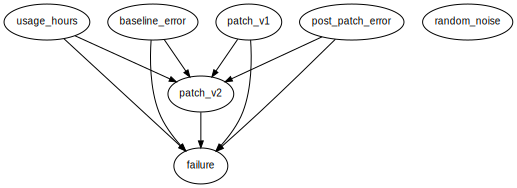

In [10]:
#causal effect: device failure
#define node order to match synthetic data columns
nodes = ["usage_hours", "baseline_error", "patch_v1", "post_patch_error", "patch_v2", "failure", "random_noise"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 0, 1, 1, 0],  # usage_hours →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_error →
    [0, 0, 0, 0, 1, 1, 0],  # patch_v1 →
    [0, 0, 0, 0, 1, 1, 0],  # post_patch_error →
    [0, 0, 0, 0, 0, 1, 0], # patch_v2 
    [0, 0, 0, 0, 0, 0, 0], # failure
    [0, 0, 0, 0, 0, 0, 0] #random_noise
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"device_failure_data_truth.csv", index=False)

show_ground_truth_dag(df)


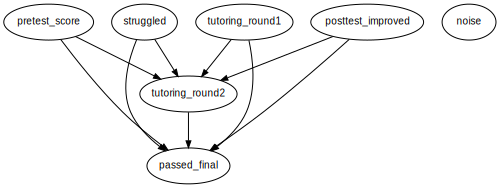

In [11]:
#causal effect: student tutoring
#define node order to match synthetic data columns
nodes = ["pretest_score", "struggled", "tutoring_round1", "posttest_improved", "tutoring_round2", "passed_final", "noise"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 0, 1, 1, 0],  # pretest_score →
    [0, 0, 0, 0, 1, 1, 0],  # struggled →
    [0, 0, 0, 0, 1, 1, 0],  # tutoring_round1 →
    [0, 0, 0, 0, 1, 1, 0],  # posttest_improved →
    [0, 0, 0, 0, 0, 1, 0], # tutoring_round2 
    [0, 0, 0, 0, 0, 0, 0], # passed_final
    [0, 0, 0, 0, 0, 0, 0] #noise
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"student_tutoring_data_truth.csv", index=False)

show_ground_truth_dag(df)


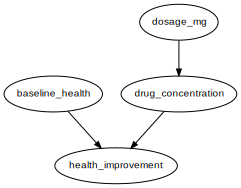

In [13]:
#causal direction: clinical trial sem
#define node order to match synthetic data columns
nodes = ["baseline_health", "dosage_mg", "drug_concentration", "health_improvement"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # baseline_health →
    [0, 0, 1, 0],  # dosage_mg →
    [0, 0, 0, 1],  # drug_concentration →
    [0, 0, 0, 0]  # health_improvement →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"clinical_trial_sem_truth.csv", index=False)

show_ground_truth_dag(df)


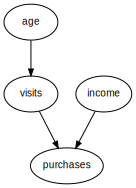

In [14]:
#causal direction: ecommerce sem
#define node order to match synthetic data columns
nodes = ["age", "income", "visits", "purchases"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 0],  # age →
    [0, 0, 0, 1],  # income →
    [0, 0, 0, 1],  # visits →
    [0, 0, 0, 0]  # purchases →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"ecommerce_sem_truth.csv", index=False)

show_ground_truth_dag(df)


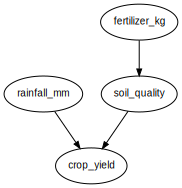

In [15]:
#causal direction: environment sem
#define node order to match synthetic data columns
nodes = ["rainfall_mm", "fertilizer_kg", "soil_quality", "crop_yield"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # rainfall_mm →
    [0, 0, 1, 0],  # fertilizer_kg →
    [0, 0, 0, 1],  # soil_quality →
    [0, 0, 0, 0]  # crop_yield →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"environment_sem_truth.csv", index=False)

show_ground_truth_dag(df)


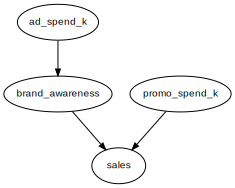

In [16]:
#causal direction: marketing sem
#define node order to match synthetic data columns
nodes = ["ad_spend_k", "promo_spend_k", "brand_awareness", "sales"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 0],  # ad_spend_k →
    [0, 0, 0, 1],  # promo_spend_k →
    [0, 0, 0, 1],  # brand_awareness →
    [0, 0, 0, 0]  # sales →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"marketing_sem_truth.csv", index=False)

show_ground_truth_dag(df)


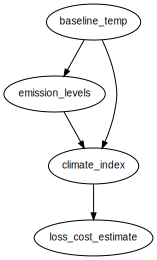

In [17]:
#counterfactual reasoning: climate impact
#define node order to match synthetic data columns
nodes = ["baseline_temp", "emission_levels", "climate_index", "loss_cost_estimate"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0],  # baseline_temp →
    [0, 0, 1, 0],  # emission_levels →
    [0, 0, 0, 1],  # climate_index →
    [0, 0, 0, 0]  # loss_cost_estimate →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"climate_impact_sem_truth.csv", index=False)

show_ground_truth_dag(df)


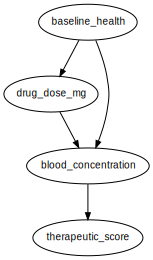

In [18]:
#counterfactual reasoning: clinical trial
#define node order to match synthetic data columns
nodes = ["baseline_health", "drug_dose_mg", "blood_concentration", "therapeutic_score"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0],  # baseline_health →
    [0, 0, 1, 0],  # drug_dose_mg →
    [0, 0, 0, 1],  # blood_concentration →
    [0, 0, 0, 0]  # therapeutic_score →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"clinical_trial_sem_truth.csv", index=False)

show_ground_truth_dag(df)


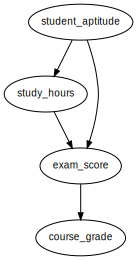

In [19]:
#counterfactual reasoning: education performance
#define node order to match synthetic data columns
nodes = ["student_aptitude", "study_hours", "exam_score", "course_grade"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0],  # student_aptitude →
    [0, 0, 1, 0],  # study_hours →
    [0, 0, 0, 1],  # exam_score →
    [0, 0, 0, 0]  # course_grade →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"education_performance_sem_truth.csv", index=False)

show_ground_truth_dag(df)


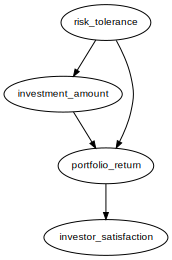

In [20]:
#counterfactual reasoning: investment outcome
#define node order to match synthetic data columns
nodes = ["risk_tolerance", "investment_amount", "portfolio_return", "investor_satisfaction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0],  # risk_tolerance →
    [0, 0, 1, 0],  # investment_amount →
    [0, 0, 0, 1],  # portfolio_return →
    [0, 0, 0, 0]  # investor_satisfaction →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"investment_outcome_sem_truth.csv", index=False)

show_ground_truth_dag(df)


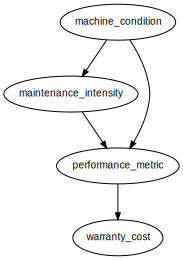

In [21]:
#counterfactual reasoning: manufacturing quality
#define node order to match synthetic data columns
nodes = ["machine_condition", "maintenance_intensity", "performance_metric", "warranty_cost"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0],  # machine_condition →
    [0, 0, 1, 0],  # maintenance_intensity →
    [0, 0, 0, 1],  # performance_metric →
    [0, 0, 0, 0]  # warranty_cost →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"manufacturing_quality_sem_truth.csv", index=False)

show_ground_truth_dag(df)


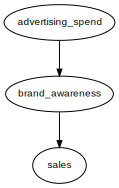

In [22]:
#dag structure markov equivalence: markequi_sem (marketing)
#define node order to match synthetic data columns
nodes = ["advertising_spend", "brand_awareness", "sales"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0],  # advertising_spend →
    [0, 0, 1],  # brand_awareness →
    [0, 0, 0]  # sales →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"dag_structure_markequi_sem_truth.csv", index=False)

show_ground_truth_dag(df)


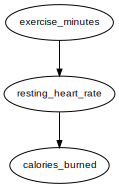

In [23]:
#dag structure markov equivalence: exercise heart rate calories
#define node order to match synthetic data columns
nodes = ["exercise_minutes", "resting_heart_rate", "calories_burned"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0],  # exercise_minutes →
    [0, 0, 1],  # resting_heart_rate →
    [0, 0, 0]  # calories_burned →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"exercse_heart_rate_calories_truth.csv", index=False)

show_ground_truth_dag(df)


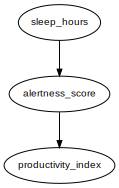

In [24]:
#dag structure markov equivalence: sleep alertness productivity
#define node order to match synthetic data columns
nodes = ["sleep_hours", "alertness_score", "productivity_index"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0],  # sleep_hours →
    [0, 0, 1],  # alertness_score →
    [0, 0, 0]  # productivity_index →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"sleep_alertness_productivity_truth.csv", index=False)

show_ground_truth_dag(df)


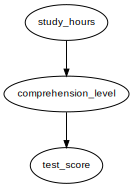

In [25]:
#dag structure markov equivalence: study comprehension testscore
#define node order to match synthetic data columns
nodes = ["study_hours", "comprehension_level", "test_score"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0],  # study_hours →
    [0, 0, 1],  # comprehension_level →
    [0, 0, 0]  # test_score →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"study_comprehension_testscore_truth.csv", index=False)

show_ground_truth_dag(df)


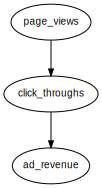

In [26]:
#dag structure markov equivalence: web traffic revenue
#define node order to match synthetic data columns
nodes = ["page_views", "click_throughs", "ad_revenue"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0],  # page_views →
    [0, 0, 1],  # click_throughs →
    [0, 0, 0]  # ad_revenue →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"web_traffic_revenue_truth.csv", index=False)

show_ground_truth_dag(df)


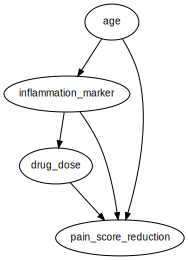

In [27]:
#domain shift: arthritis trial
#define node order to match synthetic data columns
nodes = ["age", "inflammation_marker", "drug_dose", "pain_score_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 1],  # age →
    [0, 0, 1, 1],  # inflammation_marker →
    [0, 0, 0, 1],  # drug_dose →
    [0, 0, 0, 0] #pain_score_reduction
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"arthritis_trial_truth.csv", index=False)

show_ground_truth_dag(df)


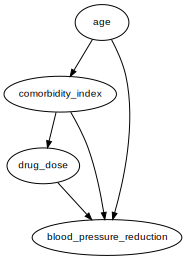

In [28]:
#domain shift: cardio trial
#define node order to match synthetic data columns
nodes = ["age", "comorbidity_index", "drug_dose", "blood_pressure_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 1],  # age →
    [0, 0, 1, 1],  # comorbidity_index →
    [0, 0, 0, 1],  # drug_dose →
    [0, 0, 0, 0] #blood_pressure_reduction
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"cardio_trial_truth.csv", index=False)

show_ground_truth_dag(df)


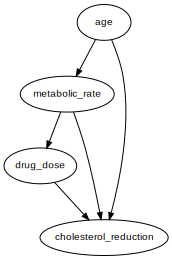

In [29]:
#domain shift: cholesterol trial
#define node order to match synthetic data columns
nodes = ["age", "metabolic_rate", "drug_dose", "cholesterol_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 1],  # age →
    [0, 0, 1, 1],  # metabolic_rate →
    [0, 0, 0, 1],  # drug_dose →
    [0, 0, 0, 0] #cholesterol_reduction
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"cholesterol_trial_truth.csv", index=False)

show_ground_truth_dag(df)


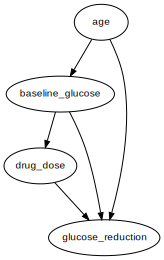

In [30]:
#domain shift: diabetes trial
#define node order to match synthetic data columns
nodes = ["age", "baseline_glucose", "drug_dose", "glucose_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 1],  # age →
    [0, 0, 1, 1],  # baseline_glucose →
    [0, 0, 0, 1],  # drug_dose →
    [0, 0, 0, 0] #glucose_reduction
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"diabetes_trial_truth.csv", index=False)

show_ground_truth_dag(df)


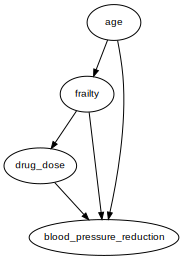

In [31]:
#domain shift: domain shift sem 
#define node order to match synthetic data columns
nodes = ["age", "frailty", "drug_dose", "blood_pressure_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 1],  # age →
    [0, 0, 1, 1],  # frailty →
    [0, 0, 0, 1],  # drug_dose →
    [0, 0, 0, 0] #blood_pressure_reduction
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"domain_shift_sem_truth.csv", index=False)

show_ground_truth_dag(df)


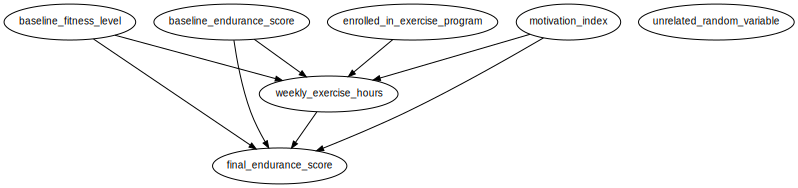

In [32]:
#mediation outcome confounder: exercise intervention study
#define node order to match synthetic data columns
nodes = ["enrolled_in_exercise_program", "baseline_fitness_level", "baseline_endurance_score", "motivation_index", "weekly_exercise_hours", "final_endurance_score", "unrelated_random_variable"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 0, 1, 0, 0],  # enrolled_in_exercise_program →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_fitness_level →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_endurance_score →
    [0, 0, 0, 0, 1, 1, 0],  # motivation_index →
    [0, 0, 0, 0, 0, 1, 0], # weekly_exercise_hours →
    [0, 0, 0, 0, 0, 0, 0], # final_endurance_score →
    [0, 0, 0, 0, 0, 0, 0] #unrelated_random_variable
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"exercise_intervention_study_truth.csv", index=False)

show_ground_truth_dag(df)


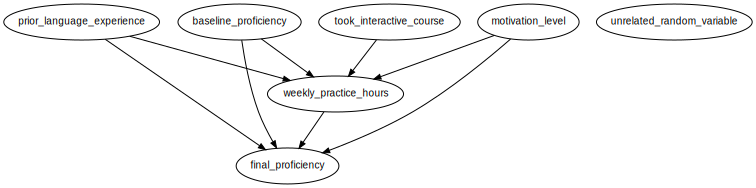

In [33]:
#mediation outcome confounder: language learning study
#define node order to match synthetic data columns
nodes = ["took_interactive_course", "prior_language_experience", "baseline_proficiency", "motivation_level", "weekly_practice_hours", "final_proficiency", "unrelated_random_variable"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 0, 1, 0, 0],  # took_interactive_course →
    [0, 0, 0, 0, 1, 1, 0],  # prior_language_experience →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_proficiency →
    [0, 0, 0, 0, 1, 1, 0],  # motivation_level →
    [0, 0, 0, 0, 0, 1, 0], # weekly_practice_hours →
    [0, 0, 0, 0, 0, 0, 0], # final_proficiency →
    [0, 0, 0, 0, 0, 0, 0] #unrelated_random_variable
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"language_learning_study_truth.csv", index=False)

show_ground_truth_dag(df)


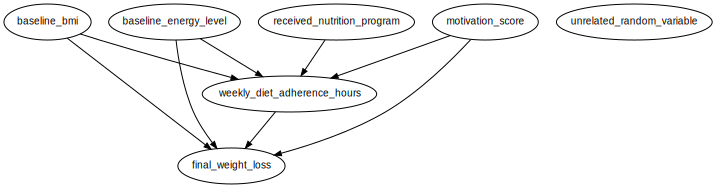

In [34]:
#mediation outcome confounder: nutrition program study
#define node order to match synthetic data columns
nodes = ["received_nutrition_program", "baseline_bmi", "baseline_energy_level", "motivation_score", "weekly_diet_adherence_hours", "final_weight_loss", "unrelated_random_variable"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 0, 1, 0, 0],  # received_nutrition_program →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_bmi →
    [0, 0, 0, 0, 1, 1, 0],  # baseline_energy_level →
    [0, 0, 0, 0, 1, 1, 0],  # motivation_score →
    [0, 0, 0, 0, 0, 1, 0], # weekly_diet_adherence_hours →
    [0, 0, 0, 0, 0, 0, 0], # final_weight_loss →
    [0, 0, 0, 0, 0, 0, 0] #unrelated_random_variable
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"nutrition_program_study_truth.csv", index=False)

show_ground_truth_dag(df)


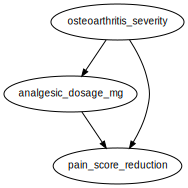

In [35]:
#moderation effect: arthritis pain reduction
#define node order to match synthetic data columns
nodes = ["osteoarthritis_severity", "analgesic_dosage_mg", "pain_score_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1],  # osteoarthritis_severity →
    [0, 0, 1],  # analgesic_dosage_mg →
    [0, 0, 0]  # pain_score_reduction →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"arthritis_pain_reduction_truth.csv", index=False)

show_ground_truth_dag(df)


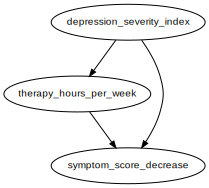

In [36]:
#moderation effect: depression symptom reduction
#define node order to match synthetic data columns
nodes = ["depression_severity_index", "therapy_hours_per_week", "symptom_score_decrease"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1],  # depression_severity_index →
    [0, 0, 1],  # therapy_hours_per_week →
    [0, 0, 0]  # symptom_score_decrease →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"depression_symptom_reduction_truth.csv", index=False)

show_ground_truth_dag(df)


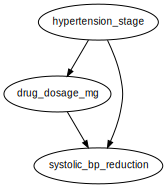

In [37]:
#moderation effect: hypertension bp reduction
#define node order to match synthetic data columns
nodes = ["hypertension_stage", "drug_dosage_mg", "systolic_bp_reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1],  # hypertension_stage →
    [0, 0, 1],  # drug_dosage_mg →
    [0, 0, 0]  # systolic_bp_reduction →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"hypertension_bp_reduction_truth.csv", index=False)

show_ground_truth_dag(df)


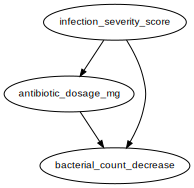

In [38]:
#moderation effect: infection bacteria reduction
#define node order to match synthetic data columns
nodes = ["infection_severity_score", "antibiotic_dosage_mg", "bacterial_count_decrease"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1],  # infection_severity_score →
    [0, 0, 1],  # antibiotic_dosage_mg →
    [0, 0, 0]  # bacterial_count_decrease →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"infection_bacteria_reduction_truth.csv", index=False)

show_ground_truth_dag(df)


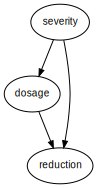

In [39]:
#moderation effect: moderation effect sem
#define node order to match synthetic data columns
nodes = ["severity", "dosage", "reduction"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1],  # severity →
    [0, 0, 1],  # dosage →
    [0, 0, 0]  # reduction →
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"moderation_effect_sem_truth.csv", index=False)

show_ground_truth_dag(df)


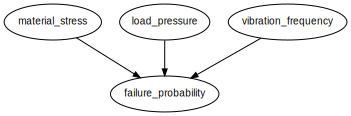

In [40]:
#necessity sufficiency: bridge integrity
#define node order to match synthetic data columns
nodes = ["material_stress", "load_pressure", "vibration_frequency", "failure_probability"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # material_stress →
    [0, 0, 0, 1],  # load_pressure →
    [0, 0, 0, 1],  # vibration_frequency →
    [0, 0, 0, 0] # failure_probability
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"bridge_integrity_truth.csv", index=False)

show_ground_truth_dag(df)


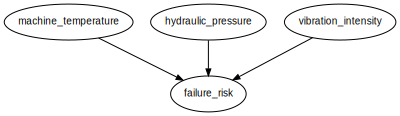

In [41]:
#necessity sufficiency: factory monitoring
#define node order to match synthetic data columns
nodes = ["machine_temperature", "hydraulic_pressure", "vibration_intensity", "failure_risk"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # machine_temperature →
    [0, 0, 0, 1],  # hydraulic_pressure →
    [0, 0, 0, 1],  # vibration_intensity →
    [0, 0, 0, 0] # failure_risk
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"factory_monitoring_truth.csv", index=False)

show_ground_truth_dag(df)


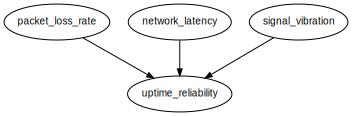

In [42]:
#necessity sufficiency: network health
#define node order to match synthetic data columns
nodes = ["packet_loss_rate", "network_latency", "signal_vibration", "uptime_reliability"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # packet_loss_rate →
    [0, 0, 0, 1],  # network_latency →
    [0, 0, 0, 1],  # signal_vibration →
    [0, 0, 0, 0] # uptime_reliability
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"network_health_truth.csv", index=False)

show_ground_truth_dag(df)


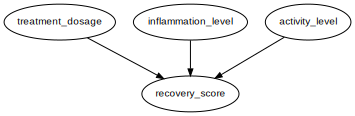

In [43]:
#necessity sufficiency: patient recovery
#define node order to match synthetic data columns
nodes = ["treatment_dosage", "inflammation_level", "activity_level", "recovery_score"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # treatment_dosage →
    [0, 0, 0, 1],  # inflammation_level →
    [0, 0, 0, 1],  # activity_level →
    [0, 0, 0, 0] # recovery_score
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"patient_recovery_truth.csv", index=False)

show_ground_truth_dag(df)


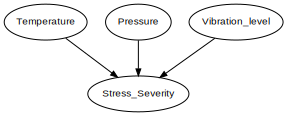

In [44]:
#necessity sufficiency: stress sem
#define node order to match synthetic data columns
nodes = ["Temperature", "Pressure", "Vibration_level", "Stress_Severity"]

#create adjacency matrix
adj = np.array([
    [0, 0, 0, 1],  # Temperature →
    [0, 0, 0, 1],  # Pressure →
    [0, 0, 0, 1],  # Vibration_level →
    [0, 0, 0, 0] # Stress_Severity
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"stress_sem_truth.csv", index=False)

show_ground_truth_dag(df)


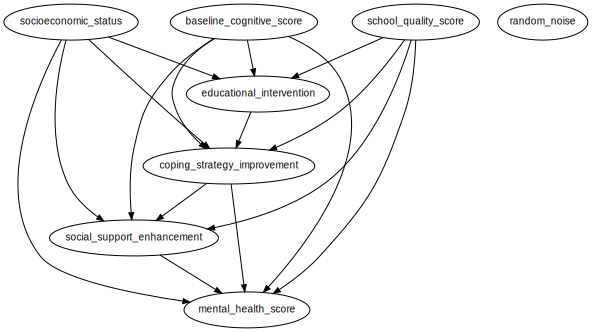

In [45]:
#sequential mediator: sequential mediation dataset
#define node order to match synthetic data columns
nodes = ["educational_intervention", "coping_strategy_improvement", "social_support_enhancement", "mental_health_score", "socioeconomic_status", "school_quality_score", "baseline_cognitive_score", "random_noise"]

#create adjacency matrix
adj = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0],  # educational_intervention →
    [0, 0, 1, 1, 0, 0, 0, 0],  # coping_strategy_improvement →
    [0, 0, 0, 1, 0, 0, 0, 0],  # social_support_enhancement →
    [0, 0, 0, 0, 0, 0, 0, 0],  # mental_health_score →
    [1, 1, 1, 1, 0, 0, 0, 0], # socioeconomic_status →
    [1, 1, 1, 1, 0, 0, 0, 0], # school_quality_score →
    [1, 1, 1, 1, 0, 0, 0, 0], #baseline_cognitive_score
    [0, 0, 0, 0, 0, 0, 0, 0] # random_noise
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"sequential_mediation_dataset_truth.csv", index=False)

show_ground_truth_dag(df)


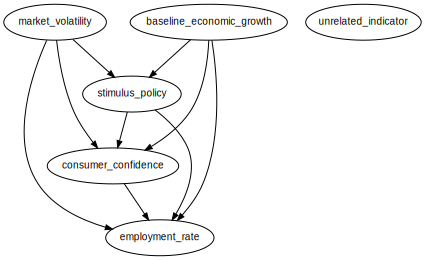

In [48]:
#treatment mediator: economic stimulus 
#define node order to match synthetic data columns
nodes = ["stimulus_policy", "consumer_confidence", "employment_rate", "market_volatility", "baseline_economic_growth", "unrelated_indicator"]

#create adjacency matrix
adj = np.array([
    [0, 1, 1, 0, 0, 0],  # stimulus_policy →
    [0, 0, 1, 0, 0, 0],  # consumer_confidence →
    [0, 0, 0, 0, 0, 0],  # employment_rate →
    [1, 1, 1, 0, 0, 0], #market_volatility
    [1, 1, 1, 0, 0, 0], # baseline_economic_growth
    [0, 0, 0, 0, 0, 0] # unrelated_indicator
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"economic_stimulus_truth.csv", index=False)

show_ground_truth_dag(df)


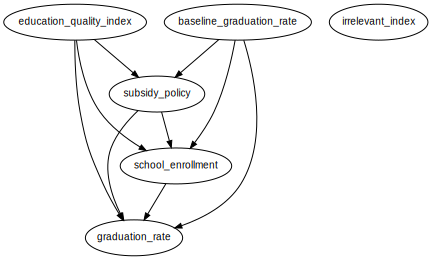

In [49]:
#treatment mediator: education subsidy policy 
#define node order to match synthetic data columns
nodes = ["education_quality_index", "baseline_graduation_rate", "subsidy_policy", "school_enrollment", "graduation_rate", "irrelevant_index"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 1, 1, 0],  # education_quality_index →
    [0, 0, 1, 1, 1, 0],  # baseline_graduation_rate →
    [0, 0, 0, 1, 1, 0],  # subsidy_policy →
    [0, 0, 0, 0, 1, 0], #school_enrollment
    [0, 0, 0, 0, 0, 0], # graduation_rate
    [0, 0, 0, 0, 0, 0] # irrelevant_index
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"education_subsidy_policy_truth.csv", index=False)

show_ground_truth_dag(df)


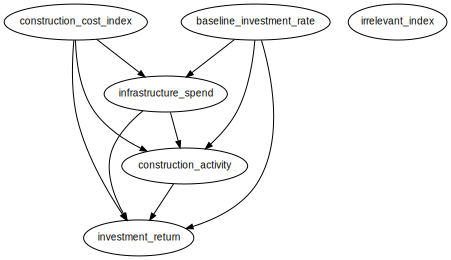

In [50]:
#treatment mediator: infrastructure spending policy 
#define node order to match synthetic data columns
nodes = ["construction_cost_index", "baseline_investment_rate", "infrastructure_spend", "construction_activity", "investment_return", "irrelevant_index"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 1, 1, 0],  # construction_cost_index →
    [0, 0, 1, 1, 1, 0],  # baseline_investment_rate →
    [0, 0, 0, 1, 1, 0],  # infrastructure_spend →
    [0, 0, 0, 0, 1, 0], #construction_activity
    [0, 0, 0, 0, 0, 0], # investment_return
    [0, 0, 0, 0, 0, 0] # irrelevant_index
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"infrastructure_spending_policy_truth.csv", index=False)

show_ground_truth_dag(df)


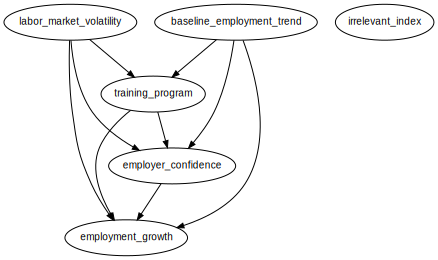

In [51]:
#treatment mediator: job training policy 
#define node order to match synthetic data columns
nodes = ["labor_market_volatility", "baseline_employment_trend", "training_program", "employer_confidence", "employment_growth", "irrelevant_index"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 1, 1, 0],  # labor_market_volatility →
    [0, 0, 1, 1, 1, 0],  # baseline_employment_trend →
    [0, 0, 0, 1, 1, 0],  # training_program →
    [0, 0, 0, 0, 1, 0], #employer_confidence
    [0, 0, 0, 0, 0, 0], # employment_growth
    [0, 0, 0, 0, 0, 0] # irrelevant_index
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"job_training_policy_truth.csv", index=False)

show_ground_truth_dag(df)


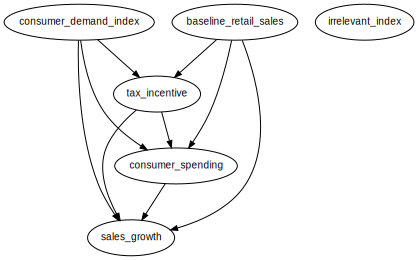

In [52]:
#treatment mediator: tax incentive policy 
#define node order to match synthetic data columns
nodes = ["consumer_demand_index", "baseline_retail_sales", "tax_incentive", "consumer_spending", "sales_growth", "irrelevant_index"]

#create adjacency matrix
adj = np.array([
    [0, 0, 1, 1, 1, 0],  # consumer_demand_index →
    [0, 0, 1, 1, 1, 0],  # baseline_retail_sales →
    [0, 0, 0, 1, 1, 0],  # tax_incentive →
    [0, 0, 0, 0, 1, 0], #consumer_spending
    [0, 0, 0, 0, 0, 0], # sales_growth
    [0, 0, 0, 0, 0, 0] # irrelevant_index
], dtype=int)

#create dataframe from adjacency matrix
df = pd.DataFrame(adj, index=nodes, columns=nodes)

#save to csv
out_path = cp_root / "ground_truth"
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path/"tax_incentive_policy_truth.csv", index=False)

show_ground_truth_dag(df)
